# Support Vector Machine: the convex optimization problem

**Goal:** understand and solve, step by step, the optimization problem that lets us find the optimal weights $(\mathbf{w}, b)$ of an SVM classifier, and verify that it is indeed a **convex optimization problem**.

This notebook covers:

1. Geometric intuition: the maximum margin.
2. **Primal** formulation (separable case / *hard margin*).
3. Primal formulation with slack variables (*soft margin*).
4. Proof of convexity of the problem.
5. **Dual** formulation via the Lagrangian and KKT conditions.
6. Numerical solution using convex optimization (`cvxpy`) — primal and dual.
7. Visualization of the hyperplane, the margin, and the support vectors.
8. Verification against `scikit-learn`.
9. Effect of the hyperparameter $C$.


## 1. Intuition: the maximum margin

Given a labeled dataset $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$, with $\mathbf{x}_i \in \mathbb{R}^d$ and $y_i \in \{-1, +1\}$, a linear classifier defines a hyperplane

$$
f(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b = 0
$$

If the data is linearly separable, infinitely many hyperplanes separate it correctly. The idea behind SVM is to pick, among all of them, the one that **maximizes the minimum distance** (the margin) between the hyperplane and the points of both classes. Intuitively, a wider margin generalizes better to unseen data.

The distance from a point $\mathbf{x}_i$ to the hyperplane is

$$
\text{dist}(\mathbf{x}_i) = \frac{|\mathbf{w}^\top \mathbf{x}_i + b|}{\|\mathbf{w}\|}
$$

If we fix the scale of $(\mathbf{w}, b)$ so that the closest points to the hyperplane satisfy $y_i(\mathbf{w}^\top \mathbf{x}_i + b) = 1$ (canonical form), the total margin between the two classes turns out to be

$$
\text{margin} = \frac{2}{\|\mathbf{w}\|}
$$

Maximizing the margin is therefore equivalent to **minimizing $\|\mathbf{w}\|$** (or, equivalently and more conveniently, $\frac{1}{2}\|\mathbf{w}\|^2$).


## 2. Primal formulation — separable case (*hard margin*)

$$
\begin{aligned}
\min_{\mathbf{w}, b} \quad & \frac{1}{2}\|\mathbf{w}\|^2 \\
\text{s.t.} \quad & y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1, \qquad i = 1, \dots, n
\end{aligned}
$$

**Why is this a convex optimization problem?**

- The objective function $\frac{1}{2}\|\mathbf{w}\|^2 = \frac{1}{2}\mathbf{w}^\top\mathbf{w}$ is a **quadratic form with the identity matrix** (positive semidefinite), and is therefore **convex** in $\mathbf{w}$.
- Each constraint $1 - y_i(\mathbf{w}^\top\mathbf{x}_i + b) \le 0$ is **affine** in $(\mathbf{w}, b)$, and every affine function is convex (and concave at the same time), so the feasible region —an intersection of half-spaces— is a **convex set**.
- Minimizing a convex function over a convex set is, by definition, a **convex program** (in fact, a *Quadratic Program*, QP). This guarantees that **any local minimum is a global minimum**, and that efficient algorithms with convergence guarantees exist.


## 3. Primal formulation — non-separable case (*soft margin*)

In practice, data is rarely perfectly separable. We introduce slack variables $\xi_i \ge 0$ that allow the margin to be violated at a certain cost, controlled by the hyperparameter $C > 0$:

$$
\begin{aligned}
\min_{\mathbf{w}, b, \boldsymbol{\xi}} \quad & \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^n \xi_i \\
\text{s.t.} \quad & y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i, \qquad i = 1,\dots,n\\
& \xi_i \ge 0, \qquad i = 1,\dots,n
\end{aligned}
$$

This is still convex: the term $C\sum \xi_i$ is linear (convex) in $\boldsymbol{\xi}$, and the additional constraints $\xi_i \ge 0$ and $y_i(\mathbf{w}^\top\mathbf{x}_i+b) \ge 1-\xi_i$ are also affine. The sum of convex functions is convex, and the intersection of convex sets is convex, so the whole problem remains a convex QP.

- Small $C$ → more margin violations are tolerated (stronger regularization, wider margin).
- Large $C$ → violations are heavily penalized (approaches the *hard margin* case).


## 4. The dual problem (Lagrangian and KKT)

We build the Lagrangian of the *soft margin* problem with multipliers $\alpha_i \ge 0$ (margin constraint) and $\mu_i \ge 0$ (constraint $\xi_i\ge0$):

$$
\mathcal{L}(\mathbf{w}, b, \boldsymbol\xi, \boldsymbol\alpha, \boldsymbol\mu) =
\frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i - \sum_i \alpha_i\big[y_i(\mathbf{w}^\top\mathbf{x}_i+b) - 1 + \xi_i\big] - \sum_i \mu_i \xi_i
$$

The optimality conditions ($\nabla_{\mathbf w}\mathcal L = 0$, $\partial_b \mathcal L = 0$, $\partial_{\xi_i}\mathcal L = 0$) give:

$$
\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i, \qquad \sum_i \alpha_i y_i = 0, \qquad \alpha_i + \mu_i = C
$$

Substituting back into $\mathcal{L}$ yields the **dual problem**, which depends only on $\boldsymbol\alpha$:

$$
\begin{aligned}
\max_{\boldsymbol\alpha} \quad & \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j y_i y_j\, \mathbf{x}_i^\top \mathbf{x}_j \\
\text{s.t.} \quad & 0 \le \alpha_i \le C, \qquad i=1,\dots,n \\
& \sum_{i=1}^n \alpha_i y_i = 0
\end{aligned}
$$

This is also a **convex quadratic problem** (maximizing a concave quadratic form, since the matrix $Q_{ij}=y_iy_j\mathbf{x}_i^\top\mathbf{x}_j$ is positive semidefinite, subject to affine constraints).

**Advantages of the dual formulation:**

- The data only appears through inner products $\mathbf{x}_i^\top\mathbf{x}_j$ → this enables the ***kernel trick*** (replacing the inner product with a kernel $K(\mathbf{x}_i,\mathbf{x}_j)$ for non-linear classification, without changing the convex structure of the problem).
- The number of variables is $n$ (number of samples) instead of $d$ (dimension), which is advantageous when $d \gg n$.
- Points with $\alpha_i > 0$ are the **support vectors**: they are the only ones that determine the optimal hyperplane, since $\mathbf{w}=\sum_i \alpha_i y_i \mathbf{x}_i$.


In [1]:
# Required libraries
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 5)


## 5. Synthetic data

We generate a 2D dataset with two linearly separable classes so we can easily visualize the hyperplane and the margin.

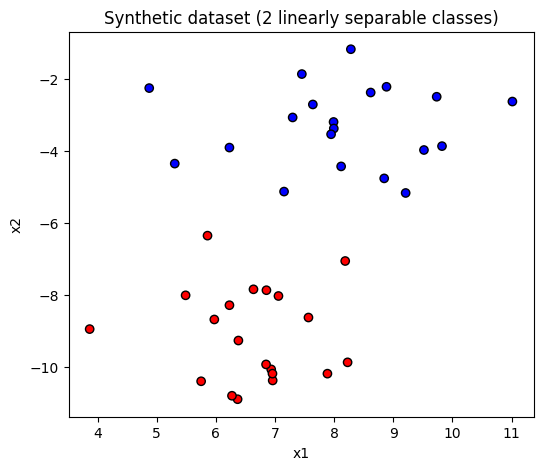

In [2]:
X, y_raw = make_blobs(n_samples=40, centers=2, cluster_std=1.2, random_state=6)
y = np.where(y_raw == 0, -1, 1)  # labels in {-1, +1}

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
plt.title("Synthetic dataset (2 linearly separable classes)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


## 6. Solving the primal (*hard margin*) with convex optimization

We use `cvxpy`, a convex optimization modeling library, to set up the QP exactly as in section 2 and solve it with an internal solver (ECOS/OSQP/Clarabel, depending on availability).

In [3]:
n, d = X.shape

w = cp.Variable(d)
b = cp.Variable()

objective = cp.Minimize(0.5 * cp.sum_squares(w))
constraints = [cp.multiply(y, X @ w + b) >= 1]

problem = cp.Problem(objective, constraints)
problem.solve()

w_opt, b_opt = w.value, b.value
print("Solver status      :", problem.status)
print("Optimal w           :", w_opt)
print("Optimal b            :", b_opt)
print("Optimal value (1/2||w||^2):", problem.value)


Solver status      : optimal
Optimal w           : [-0.37464511 -1.23828274]
Optimal b            : -4.683137445764655
Optimal value (1/2||w||^2): 0.8368515450511486


### Visualization: hyperplane, margin, and support vectors

Support vectors are the points whose constraint is active, i.e. $y_i(\mathbf{w}^\top\mathbf{x}_i + b) \approx 1$.

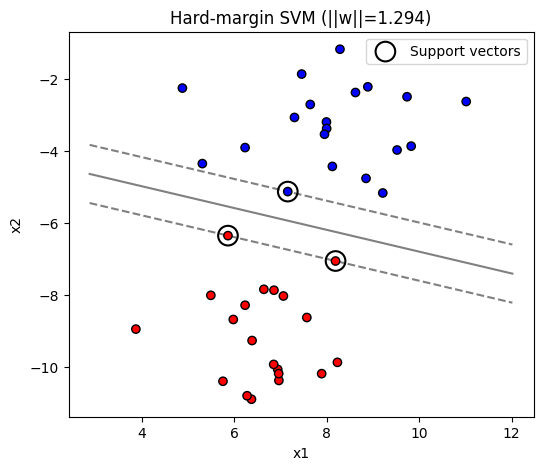

In [4]:
def plot_svm(X, y, w, b, C=None, title="SVM"):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", zorder=3)

    # Identify support vectors: |y_i (w.x_i+b) - 1| small (or < 1 if there's slack)
    margins = y * (X @ w + b)
    tol = 1e-2 if C is None else 5e-2
    sv_mask = margins <= 1 + tol
    ax.scatter(X[sv_mask, 0], X[sv_mask, 1], s=200, facecolors="none",
               edgecolors="k", linewidths=1.5, zorder=4, label="Support vectors")

    # Hyperplane and margins: w1*x1 + w2*x2 + b = k, for k in {-1,0,1}
    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    for k, style in zip([-1, 0, 1], ["--", "-", "--"]):
        x2_vals = (k - b - w[0] * x1_vals) / w[1]
        ax.plot(x1_vals, x2_vals, style, color="gray")

    ax.set_title(title)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.legend(loc="best")
    plt.show()

plot_svm(X, y, w_opt, b_opt, title=f"Hard-margin SVM (||w||={np.linalg.norm(w_opt):.3f})")


## 7. Soft margin: noisy / overlapping data

Now we generate data with more overlap (not perfectly separable) and solve the problem with slack variables, for a fixed value of $C$.

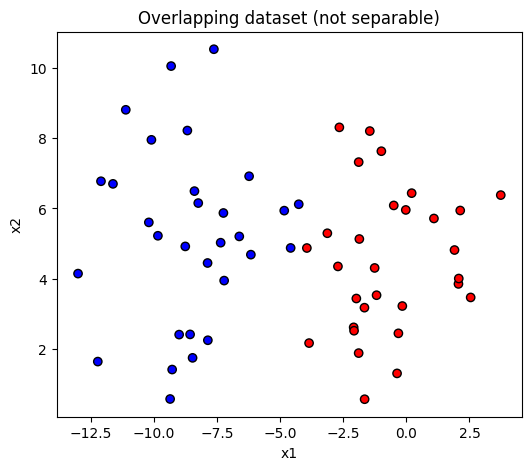

In [5]:
X2, y2_raw = make_blobs(n_samples=60, centers=2, cluster_std=2.2, random_state=7)
y2 = np.where(y2_raw == 0, -1, 1)

plt.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="bwr", edgecolors="k")
plt.title("Overlapping dataset (not separable)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


Solver status      : optimal
Optimal w           : [ 1.58751881 -0.30954108]
Optimal b            : 7.792580953048834
Sum of slacks (sum xi): 1.102556375011208


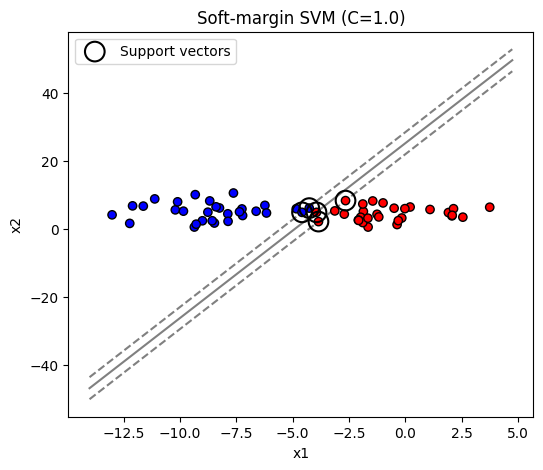

In [6]:
def solve_soft_margin_primal(X, y, C):
    n, d = X.shape
    w = cp.Variable(d)
    b = cp.Variable()
    xi = cp.Variable(n)

    objective = cp.Minimize(0.5 * cp.sum_squares(w) + C * cp.sum(xi))
    constraints = [
        cp.multiply(y, X @ w + b) >= 1 - xi,
        xi >= 0
    ]
    problem = cp.Problem(objective, constraints)
    problem.solve()
    return w.value, b.value, xi.value, problem

C = 1.0
w2_opt, b2_opt, xi_opt, prob2 = solve_soft_margin_primal(X2, y2, C)

print("Solver status      :", prob2.status)
print("Optimal w           :", w2_opt)
print("Optimal b            :", b2_opt)
print("Sum of slacks (sum xi):", xi_opt.sum())

plot_svm(X2, y2, w2_opt, b2_opt, C=C, title=f"Soft-margin SVM (C={C})")


## 8. Solving the dual problem

We set up and solve the dual (section 4) directly in $\boldsymbol\alpha$, and recover $\mathbf{w}$ and $b$ from the dual solution, verifying that it matches the primal solution.

Solver status          : optimal
w (dual)                : [ 1.58751881 -0.30954108]
b (dual)                 : 7.792580953048794
# support vectors        : 5

Primal vs. dual comparison:
  w primal: [ 1.58751881 -0.30954108]  | w dual: [ 1.58751881 -0.30954108]
  b primal: 7.792580953048834  | b dual: 7.792580953048794


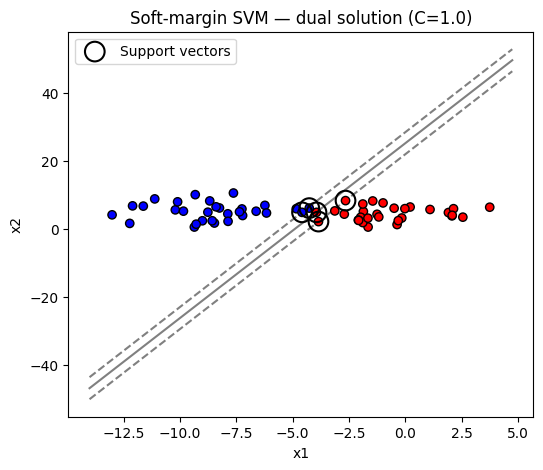

In [7]:
def solve_svm_dual(X, y, C):
    n, d = X.shape
    K = X @ X.T                       # inner-product (linear kernel) matrix
    Q = np.outer(y, y) * K            # Q_ij = y_i y_j <x_i, x_j>

    alpha = cp.Variable(n)
    objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, cp.psd_wrap(Q)))
    constraints = [alpha >= 0, alpha <= C, cp.sum(cp.multiply(alpha, y)) == 0]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    alpha_opt = alpha.value
    alpha_opt = np.clip(alpha_opt, 0, C)  # clean up numerical noise

    # Recover w = sum_i alpha_i y_i x_i
    w_dual = (alpha_opt * y) @ X

    # Recover b by averaging over "free" support vectors (0 < alpha_i < C)
    sv = (alpha_opt > 1e-4) & (alpha_opt < C - 1e-4)
    if sv.sum() == 0:
        sv = alpha_opt > 1e-4
    b_dual = np.mean(y[sv] - X[sv] @ w_dual)

    return alpha_opt, w_dual, b_dual, problem

alpha_opt, w_dual, b_dual, prob_dual = solve_svm_dual(X2, y2, C)

print("Solver status          :", prob_dual.status)
print("w (dual)                :", w_dual)
print("b (dual)                 :", b_dual)
print("# support vectors        :", np.sum(alpha_opt > 1e-4))
print("\nPrimal vs. dual comparison:")
print("  w primal:", w2_opt, " | w dual:", w_dual)
print("  b primal:", b2_opt, " | b dual:", b_dual)

plot_svm(X2, y2, w_dual, b_dual, C=C, title=f"Soft-margin SVM — dual solution (C={C})")


As expected, the **primal** and **dual** solutions coincide (up to small numerical solver differences), as guaranteed by strong duality theory for convex problems satisfying Slater's condition (here trivially satisfied, since the problem is feasible with affine constraints).

## 9. Verification against `scikit-learn`

`sklearn.svm.SVC(kernel="linear")` internally solves the same dual problem (with a specialized solver such as SMO). We compare the results.

In [8]:
clf = SVC(kernel="linear", C=C)
clf.fit(X2, y2)

w_sklearn = clf.coef_[0]
b_sklearn = clf.intercept_[0]

print("w (cvxpy, dual)   :", w_dual)
print("w (sklearn)       :", w_sklearn)
print()
print("b (cvxpy, dual)   :", b_dual)
print("b (sklearn)       :", b_sklearn)
print()
print("# support vectors (cvxpy) :", np.sum(alpha_opt > 1e-4))
print("# support vectors (sklearn):", len(clf.support_))


w (cvxpy, dual)   : [ 1.58751881 -0.30954108]
w (sklearn)       : [ 1.58723443 -0.30938105]

b (cvxpy, dual)   : 7.792580953048794
b (sklearn)       : 7.790709269898694

# support vectors (cvxpy) : 5
# support vectors (sklearn): 5


## 10. Effect of the hyperparameter $C$

$C$ controls the trade-off between maximizing the margin and minimizing classification errors (bias-variance trade-off). Let's visualize how the hyperplane changes for different values of $C$, keeping the problem convex in every case.

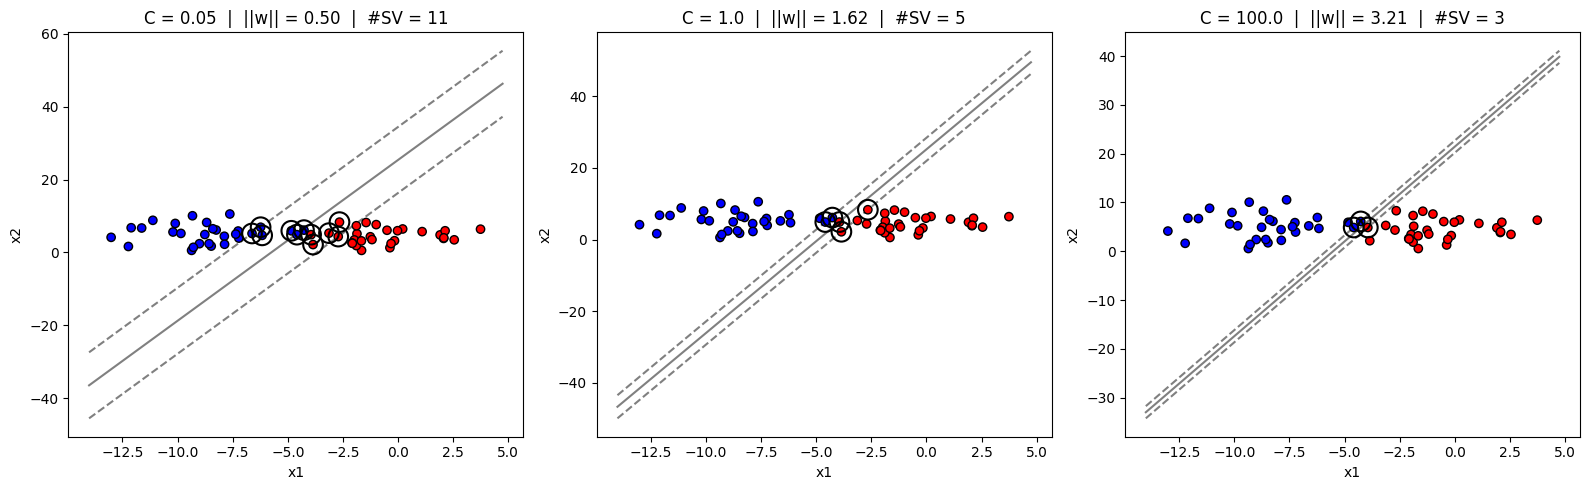

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
C_values = [0.05, 1.0, 100.0]

for ax, C_val in zip(axes, C_values):
    w_c, b_c, xi_c, _ = solve_soft_margin_primal(X2, y2, C_val)
    margins = y2 * (X2 @ w_c + b_c)
    sv_mask = margins <= 1 + 5e-2

    ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="bwr", edgecolors="k", zorder=3)
    ax.scatter(X2[sv_mask, 0], X2[sv_mask, 1], s=200, facecolors="none",
               edgecolors="k", linewidths=1.5, zorder=4)

    x1_vals = np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 200)
    for k, style in zip([-1, 0, 1], ["--", "-", "--"]):
        x2_vals = (k - b_c - w_c[0] * x1_vals) / w_c[1]
        ax.plot(x1_vals, x2_vals, style, color="gray")

    ax.set_title(f"C = {C_val}  |  ||w|| = {np.linalg.norm(w_c):.2f}  |  #SV = {sv_mask.sum()}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

plt.tight_layout()
plt.show()


We observe the expected behavior:

- **Small $C$** ($C=0.05$): the model prioritizes a wide margin and tolerates more violations → more support vectors, a "softer" boundary.
- **Large $C$** ($C=100$): the model heavily penalizes errors → narrower margin, approaching *hard margin* behavior, more sensitive to outliers.

In every case the problem being solved remains a **convex QP**, so the solver always converges to the global optimum for each fixed $C$.


## 11. Conclusions

1. Finding the optimal weights of an SVM amounts to solving a **convex quadratic program** (QP): minimizing $\frac{1}{2}\|\mathbf{w}\|^2$ (+ a linear penalty for slacks) subject to affine constraints.
2. The **convexity** of the problem —a (positive semidefinite) quadratic objective plus affine constraints— guarantees that **every local minimum is a global minimum**, and allows the use of efficient convex optimization solvers with theoretical guarantees (in this notebook, `cvxpy`).
3. The problem can be solved either in its **primal** form ($d$ variables) or its **dual** form ($n$ variables, via the Lagrangian and KKT conditions); both coincide at the optimal solution thanks to **strong duality**.
4. The dual formulation expresses everything in terms of inner products $\mathbf{x}_i^\top \mathbf{x}_j$, which opens the door to the **kernel trick** for non-linear classification without losing the problem's convex structure.
5. The results obtained with the manual `cvxpy` implementation match those of `scikit-learn`, validating the theoretical formulation.
